In [3]:
# part 4
# grover search, used for efficient searches in unordered lists via marking states
# Math library used for calculating the optimal number of Grover iterations.
import math 

# Imports from Qiskit  
# QuantumCircuit is the basic class for creating quantum circuits.
from qiskit import QuantumCircuit


# These are specialized gates and operators for building Grover's algorithm.
# GroverOperator: Handles the implementation of the Grover search algorithm.
# MCMT: Multi-controlled multi-target gate.
# ZGate: Standard Pauli-Z gate, used for phase flipping in the Grover oracle.
from qiskit.circuit.library import GroverOperator, MCMT, ZGate  

# Used to visualize the output distribution of the quantum measurements.
from qiskit.visualization import plot_distribution  


# Imports from Qiskit Runtime
# Manages the connection to IBM Quantum services.
from qiskit_ibm_runtime import QiskitRuntimeService  

# Sampler is used to execute quantum circuits and sample measurement outcomes.
from qiskit_ibm_runtime import SamplerV2 as Sampler  

In [4]:
# To run on hardware, select the backend with 
# the fewest number of jobs in the queue
# The QiskitRuntimeService connects to the IBM Quantum service, 
# allowing us to access quantum hardware.

service = QiskitRuntimeService()

# This function selects the least busy backend that is operational and not a simulator.
# By setting simulator=False, we ensure that the job runs on actual quantum hardware, not a simulator.
backend = service.least_busy(operational=True, simulator=False)

# Retrieve the name of the selected backend, which is the quantum device that will execute the job.
backend_name = backend.name
print(backend_name)

ibm_kingston


In [6]:
def grover_oracle(marked_states):
    """Build a Grover oracle for multiple marked states

    Parameters:
        marked_states (str or list): Marked states of oracle

    Returns:
        QuantumCircuit: Quantum circuit representing Grover oracle
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
    num_qubits = len(marked_states[0])
    qc = QuantumCircuit(num_qubits)

    for target in marked_states:
        rev_target = target[::-1]  # Flip bit-order to match Qiskit
        zero_inds = [ind for ind in range(num_qubits) if rev_target[ind] == '0']
        qc.x(zero_inds)
        qc.compose(MCMT(ZGate(), num_qubits - 1, 1), inplace=True)  # MCMT applies Z-gate
        qc.x(zero_inds)
    
    return qc
# note: MCMT is already going to be removed soon. wow! this stuff moves fast. replace with MCMTGate later

C:\Users\petph\AppData\Local\Temp\ipykernel_20768\1054520362.py:19: DeprecationWarning: The class ``qiskit.circuit.library.generalized_gates.mcmt.MCMT`` is deprecated as of Qiskit 1.4. It will be removed no earlier than 3 months after the release date. Use MCMTGate instead.
  qc.compose(MCMT(ZGate(), num_qubits - 1, 1), inplace=True)  # MCMT applies Z-gate


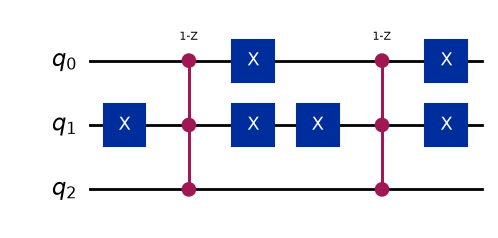

In [7]:
marked_states = ["101", "100"]
oracle = grover_oracle(marked_states)
oracle.draw(output="mpl", style="iqp")  # Visualize the oracle

C:\Users\petph\AppData\Local\Temp\ipykernel_20768\2263196012.py:1: DeprecationWarning: The class ``qiskit.circuit.library.grover_operator.GroverOperator`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.grover_operator instead.
  grover_op = GroverOperator(oracle) # also replace with grover_operator later


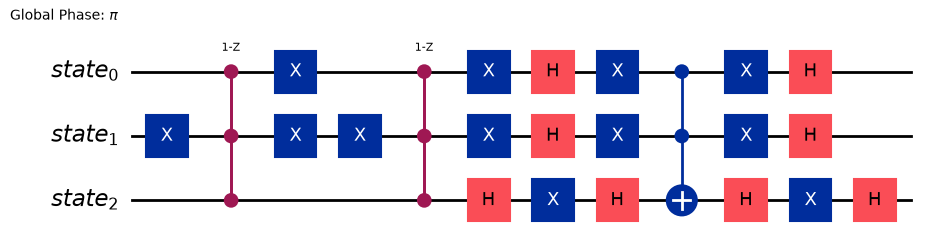

In [8]:
grover_op = GroverOperator(oracle) # also replace with grover_operator later
grover_op.decompose().draw(output="mpl", style="iqp")

In [9]:
optimal_num_iterations = math.floor(
    math.pi / (4 * math.asin(math.sqrt(len(marked_states) / 2**grover_op.num_qubits)))
)

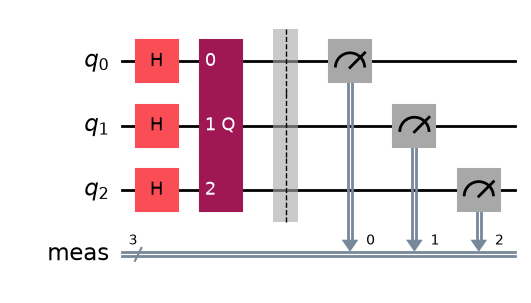

In [10]:
qc = QuantumCircuit(grover_op.num_qubits)
qc.h(range(grover_op.num_qubits))  # Apply Hadamard gates
qc.compose(grover_op.power(optimal_num_iterations), inplace=True)  # Apply Grover operator
qc.measure_all()  # Measure all qubits
qc.draw(output="mpl", style="iqp")  # Visualize the full Grover circuit

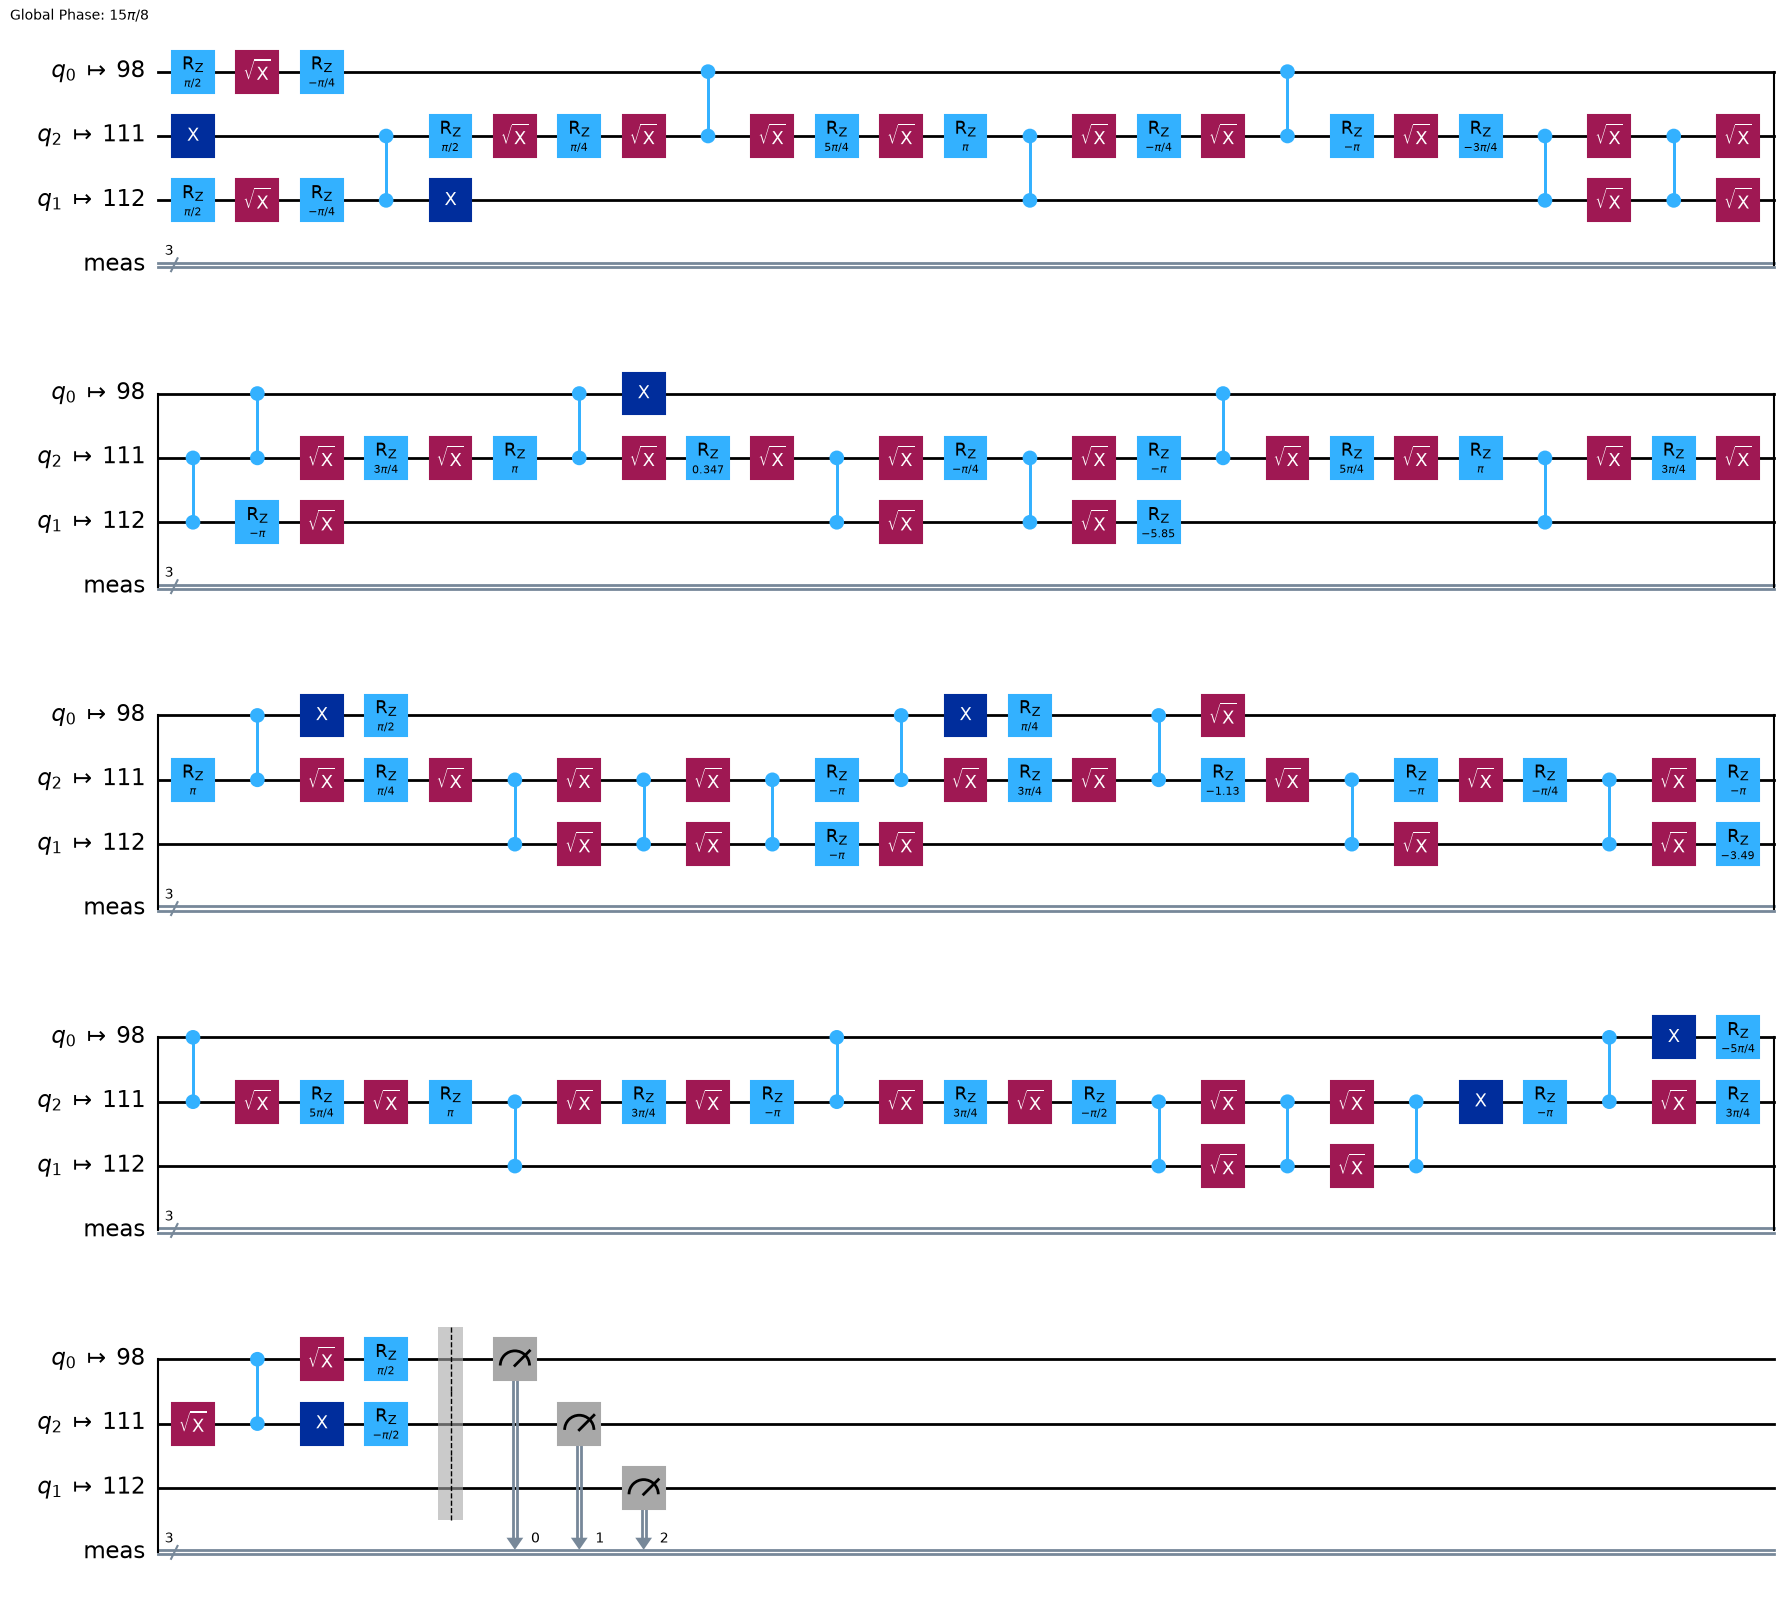

In [15]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
circuit_isa = pm.run(qc)
circuit_isa.draw(output="mpl", idle_wires=False, style="iqp")  # Visualize optimized circuit

{'100': 505, '101': 519}


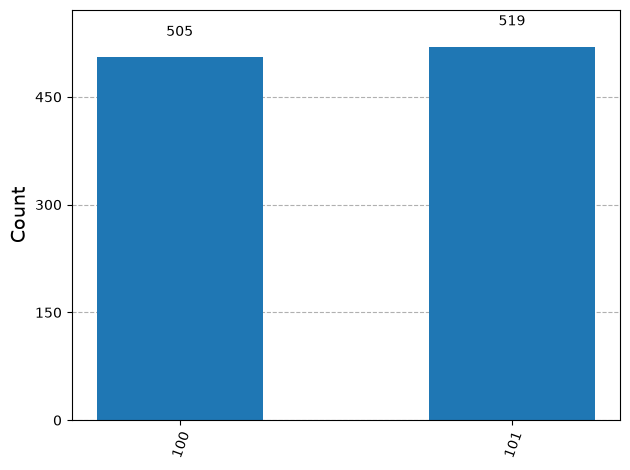

In [11]:
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

simulator = AerSimulator()
compiled_qc = transpile(qc, simulator)

job = simulator.run(compiled_qc, shots=1024)
result = job.result()
counts = result.get_counts(compiled_qc)

print(counts)
plot_histogram(counts)
# counts are of the states we marked